In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.io
import h5py
import numpy as np
import warnings
import random
import torch.nn.init as init
from scipy.io import savemat
import math
import os
import pandas as pd
warnings.filterwarnings('ignore')

with torch.no_grad():

  torch.cuda.empty_cache()

torch.set_default_dtype(torch.float64)


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Running on CPU")


Running on GPU: NVIDIA A100-SXM4-40GB


In [ ]:
#Data Loading for google colab

from google.colab import drive
drive.mount('/content/gdrive')

data = h5py.File('gdrive/MyDrive/pinn_peridynamics/3D_Pristine.mat')
#timedata = scipy.io.loadmat('gdrive/MyDrive/pinn_peridynamics/t.mat')['t']
timedata = np.arange(1, 6002) * 1e-8


Mounted at /content/gdrive


In [ ]:
layer_numbers = 3
row_numbers = np.array(data['X_zero_coord_ply'][0]).shape[0]
print(row_numbers)
first_lyr_row_numbers = int((1 / layer_numbers) * row_numbers)
print(first_lyr_row_numbers)

# input parameters (spatial and temporal coordinates)
x_sim = (np.array(data['X_zero_coord_ply'])[:, 0:first_lyr_row_numbers])*1000
y_sim = (np.array(data['Y_zero_coord_ply'])[:, 0:first_lyr_row_numbers])*1000
z_sim = (np.array(data['Z_zero_coord_ply'])[:, 0:first_lyr_row_numbers])*1000
t_sim = np.array(timedata)

# output parameters ( displacement field )
u_sim = (np.array(data['Disp_x'])[0:first_lyr_row_numbers, :])*1000
v_sim = (np.array(data['Disp_y'])[0:first_lyr_row_numbers, :])*1000
w_sim = (np.array(data['Disp_z'])[0:first_lyr_row_numbers, :])*1000



180000
60000


In [ ]:

x_sim_tile = np.tile(x_sim.T, t_sim.shape[0])
y_sim_tile = np.tile(y_sim.T, t_sim.shape[0])
z_sim_tile = np.tile(z_sim.T, t_sim.shape[0])
t_sim_tile = np.tile(t_sim.reshape(1, -1), (x_sim.shape[1], 1))


In [ ]:
# making 1D

# input numpy arrays
x_sim_flatten = x_sim_tile.flatten()[:,None]
y_sim_flatten = y_sim_tile.flatten()[:,None]
z_sim_flatten = z_sim_tile.flatten()[:,None]
t_sim_flatten = t_sim_tile.flatten()[:,None]

# output numpy arrays
u_sim_flatten = u_sim.flatten()[:,None]
v_sim_flatten = v_sim.flatten()[:,None]
w_sim_flatten = w_sim.flatten()[:,None]


In [ ]:
# input parameter
# include 3 input parameter as x, y, z t

X = np.concatenate((x_sim_flatten, y_sim_flatten, z_sim_flatten, t_sim_flatten), axis=1)

# output parameter
y = np.concatenate((u_sim_flatten, v_sim_flatten, w_sim_flatten), axis=1)


In [ ]:
# shape checking
print(X.shape)
print(y.shape)

dataset = np.concatenate((X, y), axis=1)
print(dataset.shape)


(360060000, 4)
(360060000, 3)
(360060000, 7)


In [ ]:
# download the csv file
# comment it out once the file is downloaded
# more than 10min takes to run

dataframe = pd.DataFrame(dataset)
dataframe.columns = ['x', 'y', 'z', 't', 'u', 'v', 'w']

#dataframe.to_csv('dataset.csv', index=False)
#dataframe.to_csv('gdrive/MyDrive/pinn_peridynamics/fulldataset.csv', index=False)
#np.save('gdrive/MyDrive/pinn_peridynamics/fulldataset.npy', dataset)
# When loading, just remember: columns are [x, y, z, t, u, v, w]


In [ ]:
dataframe.head()

,x,y,z,t,u,v,w
0,-149.5,-0.5,-0.0,1.000000e-08,0.0,0.0,0.0
1,-149.5,-0.5,-0.0,2.000000e-08,0.0,0.0,0.0
2,-149.5,-0.5,-0.0,3.000000e-08,0.0,0.0,0.0
3,-149.5,-0.5,-0.0,4.000000e-08,0.0,0.0,0.0
4,-149.5,-0.5,-0.0,5.000000e-08,0.0,0.0,0.0


In [ ]:
del x_sim, y_sim, z_sim, t_sim, u_sim, v_sim, w_sim
del x_sim_tile, y_sim_tile, z_sim_tile, t_sim_tile
del x_sim_flatten, y_sim_flatten, z_sim_flatten, t_sim_flatten
del u_sim_flatten, v_sim_flatten, w_sim_flatten
del X, y


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


In [ ]:
# take mixed signal from small subregion

def create_subset_from_region(
    dataset: np.ndarray, num_unique_points: int,
    time_index_ranges: list[list[int]],
    x_range: tuple[float, float] = (-3.0, 3.0),
    y_range: tuple[float, float] = (-3.0, 3.0),
    split_ratio: float = 0.5,
    tol: float = 1e-8) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Extract a spatially bounded subset with a temporal split across spatial points.

    Args:
        dataset: Array with columns [x, y, z, t, u, v, w].
        num_unique_points: Number of unique (x, y) points to sample from the region.
        time_index_ranges: List of [start, end] pairs defining Group A's time indices.
        x_range: (min_x, max_x) bounding box in x.
        y_range: (min_y, max_y) bounding box in y.
        split_ratio: Fraction of spatial points assigned to Group A (inside time ranges).
        tol: Floating-point tolerance for boundary inclusion.

    Returns:
        df_full: DataFrame with all timesteps for all selected points.
        df_partial: DataFrame combining Group A (inside time ranges) and
                    Group B (outside time ranges).
    """
    spatial_dtype = np.dtype([('x', dataset.dtype), ('y', dataset.dtype)])
    xy_struct = dataset[:, :2].view(spatial_dtype).reshape(-1)
    unique_xy_struct, unique_indices = np.unique(xy_struct, return_index=True)
    unique_xy = dataset[unique_indices, :2]

    x_mask = (unique_xy[:, 0] >= x_range[0] - tol) & (unique_xy[:, 0] <= x_range[1] + tol)
    y_mask = (unique_xy[:, 1] >= y_range[0] - tol) & (unique_xy[:, 1] <= y_range[1] + tol)
    region_points = unique_xy[x_mask & y_mask]

    if len(region_points) < num_unique_points:
        print(f"Warning: Requested {num_unique_points} points, but only {len(region_points)} available in region.")
        selected_points = region_points
    else:
        idx = np.random.choice(len(region_points), num_unique_points, replace=False)
        selected_points = region_points[idx]

    num_group_a = int(len(selected_points) * split_ratio)
    group_a_points = selected_points[:num_group_a]
    group_b_points = selected_points[num_group_a:]

    selected_struct = selected_points.view(spatial_dtype).reshape(-1)
    full_struct = dataset[:, :2].view(spatial_dtype).reshape(-1)
    mask = np.isin(full_struct, selected_struct)
    subset = dataset[mask]

    df_full = pd.DataFrame(subset, columns=['x', 'y', 'z', 't', 'u', 'v', 'w'])
    df_full = df_full.sort_values(by=['x', 'y', 'z', 't']).reset_index(drop=True)

    allowed_indices = set()
    for start, end in time_index_ranges:
        allowed_indices.update(range(start, end + 1))

    group_a_struct = group_a_points.view(spatial_dtype).reshape(-1)
    group_b_struct = group_b_points.view(spatial_dtype).reshape(-1)

    df_full['local_idx'] = df_full.groupby(['x', 'y', 'z']).cumcount()
    # Fix: Ensure the array is contiguous before viewing as a structured dtype
    full_struct_df = np.ascontiguousarray(df_full[['x', 'y']].values).view(spatial_dtype).reshape(-1)

    mask_a = np.isin(full_struct_df, group_a_struct)
    mask_b = np.isin(full_struct_df, group_b_struct)

    df_a = df_full[mask_a & df_full['local_idx'].isin(allowed_indices)]
    df_b = df_full[mask_b & ~df_full['local_idx'].isin(allowed_indices)]

    df_partial = pd.concat([df_a, df_b], ignore_index=True)
    df_partial = df_partial.drop(columns='local_idx').sort_values(by=['x', 'y', 'z', 't']).reset_index(drop=True)
    df_full = df_full.drop(columns='local_idx').reset_index(drop=True)

    print(f"Available points in region: {len(region_points)}")
    print(f"Selected: {len(selected_points)} | Group A: {len(group_a_points)} | Group B: {len(group_b_points)}")
    print(f"Full signal rows: {len(df_full)}")
    print(f"Partial signal rows: {len(df_partial)} (A: {len(df_a)}, B: {len(df_b)})")

    return df_full, df_partial




Available points in region: 72
Selected: 50 | Group A: 25 | Group B: 25
Full signal rows: 300050
Partial signal rows: 150025 (A: 79375, B: 70650)


In [ ]:
# calling function

df_full, df_partial = create_subset_from_region(
    dataset=dataset,
    num_unique_points=50,
    time_index_ranges=[[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]],
    x_range=(-6.0, 6.0),
    y_range=(-6.0, 6.0),
    split_ratio=0.5
)


In [ ]:
# Save to Excel csv
df_full.to_csv('dataset_50_spatialpoints_fullsignal_mixed_rec_neighbor_50inrange.csv', index=False)


In [ ]:
# Save to Excel csv
df_partial.to_csv('dataset_50_spatialpoints_partialsignal_mixed_rec_neighbor_50inrange.csv', index=False)


In [ ]:
def visualize_extracted_signals(df: pd.DataFrame,
                                full_dataset: np.ndarray,
                                point_indices: list[int],
                                component: str = 'u',
                                time_index_ranges: list[list[int]] | None = None,
                                save_dir: str = '.',
                                figsize: tuple[float, float] = (14, 3.5)) -> None:
    """Plot two figures per point: Group A and Group B segments overlaid on full signal.

    Args:
        df: Filtered DataFrame with columns ['x', 'y', 'z', 't', 'u', 'v', 'w'].
        full_dataset: Original unfiltered dataset array, shape (N, 7).
        point_indices: Which unique (x, y, z) groups to plot, by integer index.
        component: Displacement component to plot ('u', 'v', or 'w').
        time_index_ranges: List of [start, end] ranges defining Group A windows.
        save_dir: Directory to save individual JPEG files.
        figsize: (width, height) for each figure.
    """
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    from matplotlib.lines import Line2D
    import os

    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Inter', 'Helvetica', 'Arial'],
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.grid': False,
        'axes.edgecolor': '#2C2C2A',
        'axes.labelcolor': '#212529',
        'xtick.color': '#2C2C2A',
        'ytick.color': '#2C2C2A',
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
    })

    comp_idx = {'u': 4, 'v': 5, 'w': 6}[component]
    dt = 1e-8
    full_line_color = '#212529'
    color_a = '#DC2626'
    color_b = '#2563EB'

    groups = list(df.groupby(['x', 'y', 'z'], sort=True))
    os.makedirs(save_dir, exist_ok=True)

    sorted_ranges = sorted(time_index_ranges, key=lambda r: r[0])

    for pidx in point_indices:
        key, grp = groups[pidx]
        x_val, y_val, z_val = key

        mask = ((np.abs(full_dataset[:, 0] - x_val) < 1e-8) &
                (np.abs(full_dataset[:, 1] - y_val) < 1e-8) &
                (np.abs(full_dataset[:, 2] - z_val) < 1e-8))
        full_grp = full_dataset[mask]
        sort_order = np.argsort(full_grp[:, 3])
        full_grp = full_grp[sort_order]
        full_signal = full_grp[:, comp_idx]
        full_indices = np.round(full_grp[:, 3] / dt - 1).astype(int)

        grp_sorted = grp.sort_values('t').reset_index(drop=True)
        orig_indices = np.round(grp_sorted['t'].values / dt - 1).astype(int)
        seg_signal = grp_sorted[component].values

        idx_min = int(full_indices.min())
        idx_max = int(full_indices.max())
        complement = []
        prev_end = idx_min
        for start, end in sorted_ranges:
            if prev_end < start:
                complement.append([prev_end, start - 1])
            prev_end = max(prev_end, end + 1)
        if prev_end <= idx_max:
            complement.append([prev_end, idx_max])

        group_configs = [
            ('Group A (inside ranges)', color_a, sorted_ranges, 'groupA'),
            ('Group B (outside ranges)', color_b, complement, 'groupB'),
        ]

        for label, color, span_ranges, tag in group_configs:
            fig, ax = plt.subplots(1, 1, figsize=figsize)
            ax.plot(full_indices, full_signal, color=full_line_color, linewidth=1.2, zorder=1)

            for start, end in span_ranges:
                seg_mask = (orig_indices >= start) & (orig_indices <= end)
                if seg_mask.any():
                    ax.plot(orig_indices[seg_mask], seg_signal[seg_mask],
                            color=color, linewidth=2.5, linestyle='--',
                            zorder=2, alpha=0.9)
                ax.axvspan(start, end, color=color, alpha=0.07, zorder=0)

            ax.set_ylabel(f'{component}', fontsize=14, fontweight=500)
            ax.set_xlabel('Timestep index', fontsize=14, fontweight=500)
            ax.tick_params(labelsize=12, width=1.0, length=4)
            ax.spines[:].set_linewidth(0.8)

            legend_elements = [
                Line2D([0], [0], color=full_line_color, linewidth=1.2, label='Full signal'),
                Line2D([0], [0], color=color, linewidth=2.5, linestyle='--', label=label),
            ]
            coord_label = f'(x={x_val:.1f}, y={y_val:.1f}) — {label}'
            ax.set_title(coord_label, fontsize=13, fontweight=500, color='#2C2C2A', pad=10)
            ax.legend(handles=legend_elements, fontsize=11, loc='upper center',
                      frameon=True, edgecolor='#B4B2A9', facecolor='white',
                      ncol=2, bbox_to_anchor=(0.5, 1.0))

            plt.tight_layout()
            fname = os.path.join(save_dir, f'signal_point{pidx}_{component}_{tag}.jpg')
            fig.savefig(fname, format='jpeg', dpi=300, bbox_inches='tight',
                        facecolor='white')
            plt.show()
            print(f'Saved: {fname}')


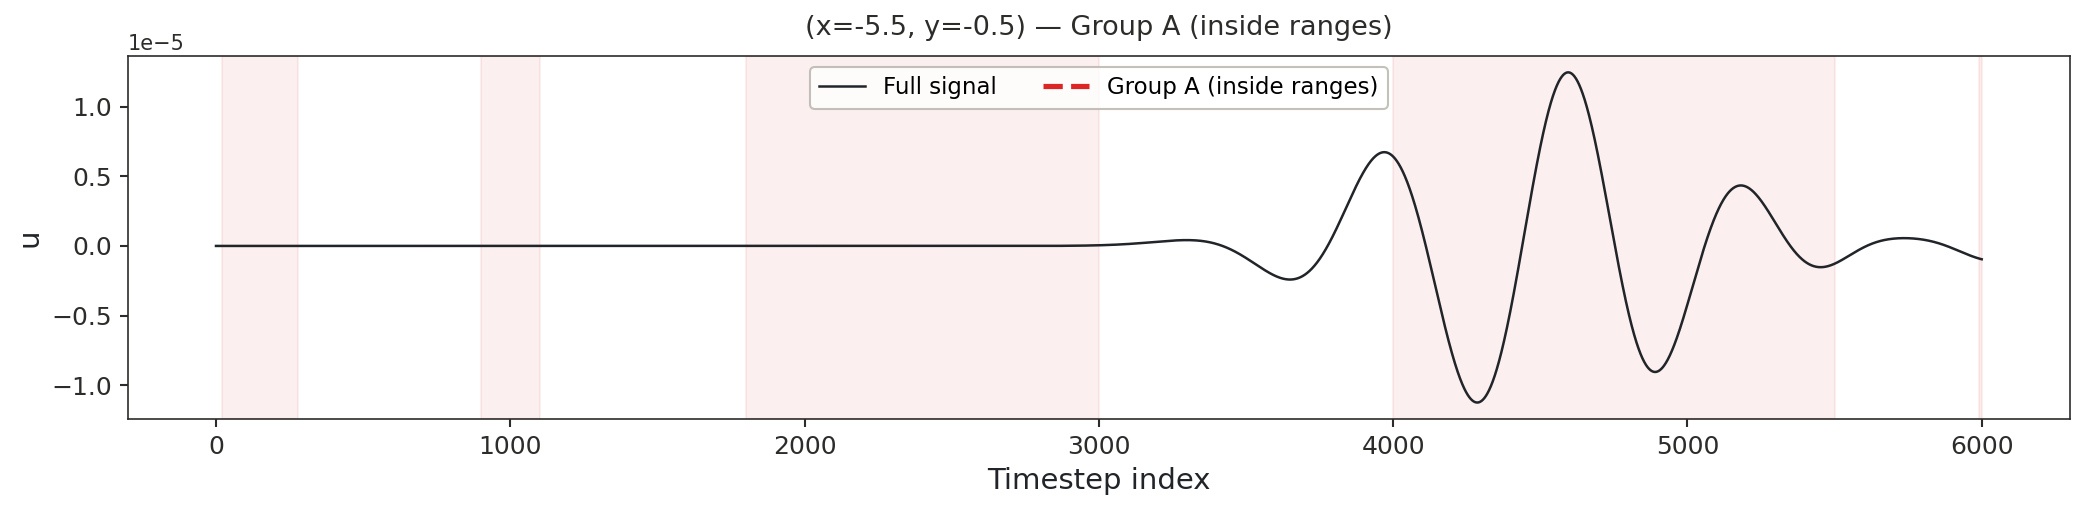

Saved: ./signal_plots/signal_point3_u_groupA.jpg


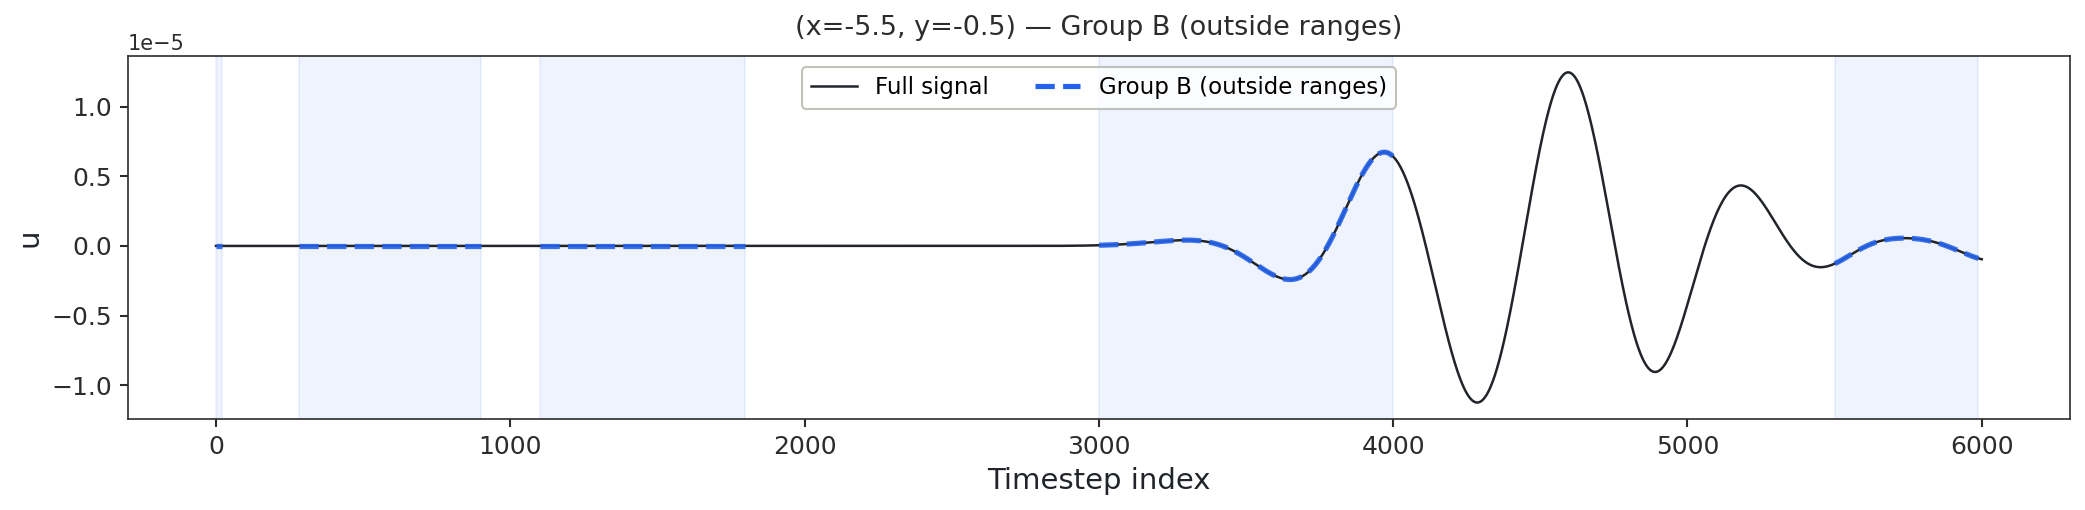

Saved: ./signal_plots/signal_point3_u_groupB.jpg


In [ ]:
visualize_extracted_signals(
    df=df_partial,
    full_dataset=dataset,
    point_indices=[ 3],
    component='u',
    time_index_ranges=[[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]],
    save_dir='./signal_plots'
)

In [ ]:
def visualize_extracted_signals(df: pd.DataFrame,
                                full_dataset: np.ndarray,
                                point_indices: list[int],
                                component: str = 'u',
                                time_index_ranges: list[list[int]] | None = None,
                                save_dir: str = '.',
                                figsize: tuple[float, float] = (14, 3.5)) -> None:
    """Plot two figures per point: Group A and Group B segments overlaid on full signal.

    Args:
        df: Filtered DataFrame with columns ['x', 'y', 'z', 't', 'u', 'v', 'w'].
        full_dataset: Original unfiltered dataset array, shape (N, 7).
        point_indices: Which unique (x, y, z) groups to plot, by integer index.
        component: Displacement component to plot ('u', 'v', or 'w').
        time_index_ranges: List of [start, end] ranges defining Group A windows.
        save_dir: Directory to save individual JPEG files.
        figsize: (width, height) for each figure.
    """
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    from matplotlib.lines import Line2D
    import os

    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Inter', 'Helvetica', 'Arial'],
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.grid': False,
        'axes.edgecolor': '#2C2C2A',
        'axes.labelcolor': '#212529',
        'xtick.color': '#2C2C2A',
        'ytick.color': '#2C2C2A',
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
    })

    comp_idx = {'u': 4, 'v': 5, 'w': 6}[component]
    dt = 1e-8
    full_line_color = '#212529'
    color_a = '#DC2626'
    color_b = '#2563EB'

    groups = list(df.groupby(['x', 'y', 'z'], sort=True))
    os.makedirs(save_dir, exist_ok=True)

    sorted_ranges = sorted(time_index_ranges, key=lambda r: r[0])

    for pidx in point_indices:
        key, grp = groups[pidx]
        x_val, y_val, z_val = key

        mask = ((np.abs(full_dataset[:, 0] - x_val) < 1e-8) &
                (np.abs(full_dataset[:, 1] - y_val) < 1e-8) &
                (np.abs(full_dataset[:, 2] - z_val) < 1e-8))
        full_grp = full_dataset[mask]
        sort_order = np.argsort(full_grp[:, 3])
        full_grp = full_grp[sort_order]
        full_signal = full_grp[:, comp_idx]
        full_indices = np.round(full_grp[:, 3] / dt - 1).astype(int)

        idx_min = int(full_indices.min())
        idx_max = int(full_indices.max())
        complement = []
        prev_end = idx_min
        for start, end in sorted_ranges:
            if prev_end < start:
                complement.append([prev_end, start - 1])
            prev_end = max(prev_end, end + 1)
        if prev_end <= idx_max:
            complement.append([prev_end, idx_max])

        group_configs = [
            ('Group A (inside ranges)', color_a, sorted_ranges, 'groupA'),
            ('Group B (outside ranges)', color_b, complement, 'groupB'),
        ]

        for label, color, span_ranges, tag in group_configs:
            fig, ax = plt.subplots(1, 1, figsize=figsize)
            ax.plot(full_indices, full_signal, color=full_line_color, linewidth=1.2, zorder=1)

            for start, end in span_ranges:
                seg_mask = (full_indices >= start) & (full_indices <= end)
                if seg_mask.any():
                    ax.plot(full_indices[seg_mask], full_signal[seg_mask],
                            color=color, linewidth=2.5, linestyle='--',
                            zorder=2, alpha=0.9)
                ax.axvspan(start, end, color=color, alpha=0.07, zorder=0)

            ax.set_ylabel(f'{component}', fontsize=14, fontweight=500)
            ax.set_xlabel('Timestep index', fontsize=14, fontweight=500)
            ax.tick_params(labelsize=12, width=1.0, length=4)
            ax.spines[:].set_linewidth(0.8)

            legend_elements = [
                Line2D([0], [0], color=full_line_color, linewidth=1.2, label='Full signal'),
                Line2D([0], [0], color=color, linewidth=2.5, linestyle='--', label=label),
            ]
            coord_label = f'(x={x_val:.1f}, y={y_val:.1f}) — {label}'
            ax.set_title(coord_label, fontsize=13, fontweight=500, color='#2C2C2A', pad=10)
            ax.legend(handles=legend_elements, fontsize=11, loc='upper center',
                      frameon=True, edgecolor='#B4B2A9', facecolor='white',
                      ncol=2, bbox_to_anchor=(0.5, 1.0))

            plt.tight_layout()
            fname = os.path.join(save_dir, f'signal_point{pidx}_{component}_{tag}.jpg')
            fig.savefig(fname, format='jpeg', dpi=300, bbox_inches='tight',
                        facecolor='white')
            plt.show()
            print(f'Saved: {fname}')


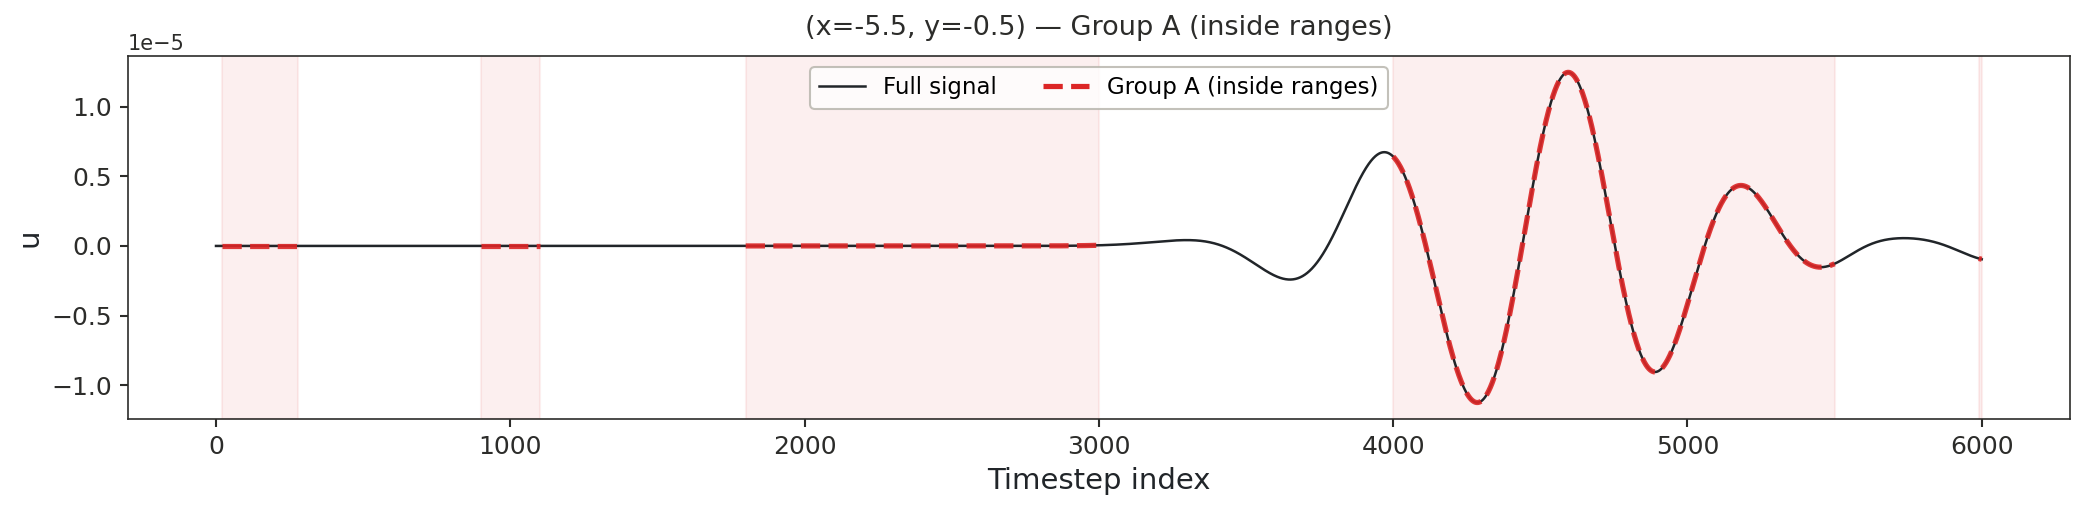

Saved: ./signal_plots/signal_point3_u_groupA.jpg


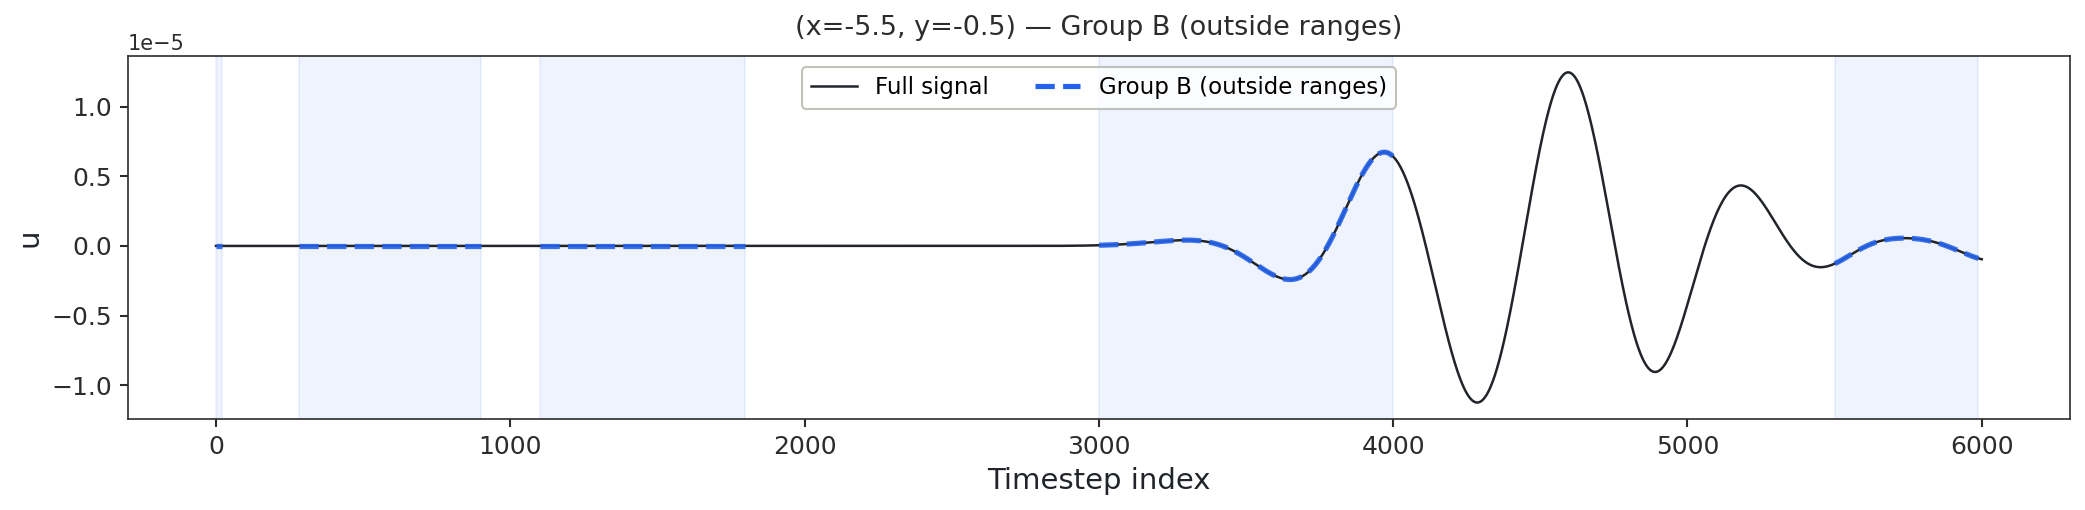

Saved: ./signal_plots/signal_point3_u_groupB.jpg


In [ ]:
visualize_extracted_signals(
    df=df_partial,
    full_dataset=dataset,
    point_indices=[ 3],
    component='u',
    time_index_ranges=[[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]],
    save_dir='./signal_plots'
)

In [ ]:
def create_subset_with_spatial_constraint(dataset: np.ndarray, num_unique_points: int,
                                          time_index_ranges: list[list[int]],
                                          inside_ratio: float = 0.7,
                                          x_range=(-50.0, 50.0), y_range=(-150.0, -50.0),
                                          tol: float = 1e-8) -> tuple[pd.DataFrame, pd.DataFrame]:

    # === Step 1: Extract unique spatial points ===
    spatial_dtype = np.dtype([('x', dataset.dtype), ('y', dataset.dtype)])
    xy_struct = dataset[:, :2].view(spatial_dtype).reshape(-1)
    unique_xy_struct, unique_indices = np.unique(xy_struct, return_index=True)
    unique_xy = dataset[unique_indices, :2]

    # === Step 2: Inside/outside spatial masks with tolerance ===
    x_mask = (unique_xy[:, 0] >= x_range[0] - tol) & (unique_xy[:, 0] <= x_range[1] + tol)
    y_mask = (unique_xy[:, 1] >= y_range[0] - tol) & (unique_xy[:, 1] <= y_range[1] + tol)
    inside_mask = x_mask & y_mask

    inside_points = unique_xy[inside_mask]
    outside_points = unique_xy[~inside_mask]

    # === Step 3: Sample spatial points (with fallback) ===
    num_inside = int(num_unique_points * inside_ratio)
    num_outside = num_unique_points - num_inside

    available_inside = min(len(inside_points), num_inside)
    available_outside = min(len(outside_points), num_outside)

    if available_inside < num_inside:
        print(f"Warning: Requested {num_inside} inside points, but only {available_inside} available.")
    if available_outside < num_outside:
        print(f"Warning: Requested {num_outside} outside points, but only {available_outside} available.")

    selected_inside = inside_points[np.random.choice(len(inside_points), available_inside, replace=False)] if available_inside > 0 else np.empty((0, 2))
    selected_outside = outside_points[np.random.choice(len(outside_points), available_outside, replace=False)] if available_outside > 0 else np.empty((0, 2))

    selected_points = np.vstack((selected_inside, selected_outside))
    selected_struct = selected_points.view(spatial_dtype).reshape(-1)

    # === Step 4: Filter rows matching selected spatial points ===
    full_struct = dataset[:, :2].view(spatial_dtype).reshape(-1)
    mask = np.isin(full_struct, selected_struct)
    subset = dataset[mask]

    df_full = pd.DataFrame(subset, columns=['x', 'y', 'z', 't', 'u', 'v', 'w'])
    df_full = df_full.sort_values(by=['x', 'y', 'z', 't']).reset_index(drop=True)

    # === Step 5: Temporal filtering for partial signal ===
    allowed_indices = set()
    for start, end in time_index_ranges:
        allowed_indices.update(range(start, end + 1))

    df_full['local_idx'] = df_full.groupby(['x', 'y', 'z']).cumcount()
    df_partial = df_full[df_full['local_idx'].isin(allowed_indices)].drop(columns='local_idx').reset_index(drop=True)
    df_full = df_full.drop(columns='local_idx').reset_index(drop=True)

    # === Step 6: Sanity check ===
    spatial_subset = df_full[['x', 'y']].drop_duplicates()
    x_check = (spatial_subset['x'] >= x_range[0] - tol) & (spatial_subset['x'] <= x_range[1] + tol)
    y_check = (spatial_subset['y'] >= y_range[0] - tol) & (spatial_subset['y'] <= y_range[1] + tol)
    inside_count = (x_check & y_check).sum()
    outside_count = len(spatial_subset) - inside_count

    print(f"Total unique spatial points selected: {len(spatial_subset)}")
    print(f"Inside-region points: {inside_count} ({100*inside_count/len(spatial_subset):.2f}%)")
    print(f"Outside-region points: {outside_count} ({100*outside_count/len(spatial_subset):.2f}%)")
    print(f"Full signal rows: {len(df_full)}")
    print(f"Partial signal rows: {len(df_partial)} (ranges: {time_index_ranges})")

    return df_full, df_partial


In [ ]:
df_full, df_partial = create_subset_with_spatial_constraint(
    dataset, num_unique_points=500,
    time_index_ranges=[[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]]
)


Total unique spatial points selected: 500
Inside-region points: 350 (70.00%)
Outside-region points: 150 (30.00%)
Full signal rows: 3000500
Partial signal rows: 1587500 (ranges: [[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]])


In [ ]:
def create_subset_with_spatial_constraint(dataset: np.ndarray, num_unique_points: int,
                                          time_index_ranges: list[list[int]],
                                          num_in_range: int,
                                          inside_ratio: float = 0.7,
                                          x_range=(-50.0, 50.0), y_range=(-150.0, -50.0),
                                          tol: float = 1e-8) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Args:
        num_unique_points: Total unique (x, y) pairs to select.
        time_index_ranges: Timestep index ranges for the in-range group.
        num_in_range: How many of the selected points get the in-range signal.
                      The rest get the complement (out-of-range signal).
    """

    # === Step 1: Extract unique spatial points ===
    spatial_dtype = np.dtype([('x', dataset.dtype), ('y', dataset.dtype)])
    xy_struct = dataset[:, :2].view(spatial_dtype).reshape(-1)
    unique_xy_struct, unique_indices = np.unique(xy_struct, return_index=True)
    unique_xy = dataset[unique_indices, :2]

    # === Step 2: Inside/outside spatial masks with tolerance ===
    x_mask = (unique_xy[:, 0] >= x_range[0] - tol) & (unique_xy[:, 0] <= x_range[1] + tol)
    y_mask = (unique_xy[:, 1] >= y_range[0] - tol) & (unique_xy[:, 1] <= y_range[1] + tol)
    inside_mask = x_mask & y_mask

    inside_points = unique_xy[inside_mask]
    outside_points = unique_xy[~inside_mask]

    # === Step 3: Sample spatial points (with fallback) ===
    num_inside = int(num_unique_points * inside_ratio)
    num_outside = num_unique_points - num_inside

    available_inside = min(len(inside_points), num_inside)
    available_outside = min(len(outside_points), num_outside)

    if available_inside < num_inside:
        print(f"Warning: Requested {num_inside} inside points, but only {available_inside} available.")
    if available_outside < num_outside:
        print(f"Warning: Requested {num_outside} outside points, but only {available_outside} available.")

    selected_inside = inside_points[np.random.choice(len(inside_points), available_inside, replace=False)] if available_inside > 0 else np.empty((0, 2))
    selected_outside = outside_points[np.random.choice(len(outside_points), available_outside, replace=False)] if available_outside > 0 else np.empty((0, 2))

    selected_points = np.vstack((selected_inside, selected_outside))

    # === Step 4: Split selected points into in-range and out-of-range groups ===
    num_out_range = len(selected_points) - num_in_range
    perm = np.random.permutation(len(selected_points))
    in_range_points = selected_points[perm[:num_in_range]]
    out_range_points = selected_points[perm[num_in_range:]]

    # === Step 5: Filter full dataset rows ===
    selected_struct = selected_points.view(spatial_dtype).reshape(-1)
    full_struct = dataset[:, :2].view(spatial_dtype).reshape(-1)
    mask = np.isin(full_struct, selected_struct)
    subset = dataset[mask]

    df_full = pd.DataFrame(subset, columns=['x', 'y', 'z', 't', 'u', 'v', 'w'])
    df_full = df_full.sort_values(by=['x', 'y', 'z', 't']).reset_index(drop=True)

    # === Step 6: Build allowed and complement index sets ===
    allowed_indices = set()
    for start, end in time_index_ranges:
        allowed_indices.update(range(start, end + 1))

    # Determine max timestep index from data
    max_idx = df_full.groupby(['x', 'y', 'z']).size().max()
    complement_indices = set(range(max_idx)) - allowed_indices

    # === Step 7: Tag each point as in-range or out-of-range ===
    in_range_struct = in_range_points.view(spatial_dtype).reshape(-1)
    out_range_struct = out_range_points.view(spatial_dtype).reshape(-1)
    full_xy_struct = np.ascontiguousarray(df_full[['x', 'y']].values).view(spatial_dtype).reshape(-1)

    is_in_range = np.isin(full_xy_struct, in_range_struct)
    is_out_range = np.isin(full_xy_struct, out_range_struct)

    df_full['local_idx'] = df_full.groupby(['x', 'y', 'z']).cumcount()

    mask_partial = (is_in_range & df_full['local_idx'].isin(allowed_indices)) | \
                   (is_out_range & df_full['local_idx'].isin(complement_indices))

    df_partial = df_full[mask_partial].drop(columns='local_idx').reset_index(drop=True)
    df_full = df_full.drop(columns='local_idx').reset_index(drop=True)

    # === Step 8: Sanity check ===
    spatial_subset = df_full[['x', 'y']].drop_duplicates()
    x_check = (spatial_subset['x'] >= x_range[0] - tol) & (spatial_subset['x'] <= x_range[1] + tol)
    y_check = (spatial_subset['y'] >= y_range[0] - tol) & (spatial_subset['y'] <= y_range[1] + tol)
    inside_count = (x_check & y_check).sum()
    outside_count = len(spatial_subset) - inside_count

    print(f"Total unique spatial points selected: {len(spatial_subset)}")
    print(f"Inside-region points: {inside_count} ({100*inside_count/len(spatial_subset):.2f}%)")
    print(f"Outside-region points: {outside_count} ({100*outside_count/len(spatial_subset):.2f}%)")
    print(f"In-range signal points: {num_in_range}, Out-of-range signal points: {num_out_range}")
    print(f"Full signal rows: {len(df_full)}")
    print(f"Partial signal rows: {len(df_partial)}")

    return df_full, df_partial


In [ ]:
df_full, df_partial = create_subset_with_spatial_constraint(
    dataset, num_unique_points=50,
    time_index_ranges=[[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]],
    num_in_range=30
)



Total unique spatial points selected: 50
Inside-region points: 35 (70.00%)
Outside-region points: 15 (30.00%)
In-range signal points: 30, Out-of-range signal points: 20
Full signal rows: 300050
Partial signal rows: 151770


In [ ]:
df_full.head()

,x,y,z,t,u,v,w
0,-148.5,-35.5,-0.0,1.000000e-08,0.0,0.0,0.0
1,-148.5,-35.5,-0.0,2.000000e-08,0.0,0.0,0.0
2,-148.5,-35.5,-0.0,3.000000e-08,0.0,0.0,0.0
3,-148.5,-35.5,-0.0,4.000000e-08,0.0,0.0,0.0
4,-148.5,-35.5,-0.0,5.000000e-08,0.0,0.0,0.0


In [ ]:
# Save to Excel csv
df_full.to_csv('dataset_50_spatialpoints_fullsignal_mixed_70ratio_30inrange.csv', index=False)


In [ ]:
# Save to Excel csv
df_partial.to_csv('dataset_500_spatialpoints_partialsignal_mixed_70ratio_30inrange.csv', index=False)


In [ ]:
def visualize_extracted_signals(df: pd.DataFrame,
                                full_dataset: np.ndarray,
                                point_indices: list[int],
                                component: str = 'u',
                                time_index_ranges: list[list[int]] | None = None,
                                save_dir: str = '.',
                                figsize: tuple[float, float] = (14, 3.5)) -> None:
    """Plot extracted signal segments overlaid on full signal, one file per point.

    Args:
        df: Filtered DataFrame with columns ['x', 'y', 'z', 't', 'u', 'v', 'w'].
        full_dataset: Original unfiltered dataset array, shape (N, 7): [x, y, z, t, u, v, w].
        point_indices: Which unique (x, y, z) groups to plot, by integer index.
        component: Displacement component to plot ('u', 'v', or 'w').
        time_index_ranges: List of [start, end] ranges to highlight. If None, highlights all.
        save_dir: Directory to save individual JPEG files.
        figsize: (width, height) for each figure.
    """
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    from matplotlib.lines import Line2D
    import os

    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Inter', 'Helvetica', 'Arial'],
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.grid': False,
        'axes.edgecolor': '#2C2C2A',
        'axes.labelcolor': '#212529',
        'xtick.color': '#2C2C2A',
        'ytick.color': '#2C2C2A',
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
    })

    comp_idx = {'u': 4, 'v': 5, 'w': 6}[component]
    dt = 1e-8
    full_line_color = '#212529'
    extract_color = '#DC2626'

    groups = list(df.groupby(['x', 'y', 'z'], sort=True))
    os.makedirs(save_dir, exist_ok=True)

    for pidx in point_indices:
        key, grp = groups[pidx]
        x_val, y_val, z_val = key

        mask = ((np.abs(full_dataset[:, 0] - x_val) < 1e-8) &
                (np.abs(full_dataset[:, 1] - y_val) < 1e-8) &
                (np.abs(full_dataset[:, 2] - z_val) < 1e-8))
        full_grp = full_dataset[mask]
        sort_order = np.argsort(full_grp[:, 3])
        full_grp = full_grp[sort_order]
        full_signal = full_grp[:, comp_idx]
        full_indices = np.round(full_grp[:, 3] / dt - 1).astype(int)

        fig, ax = plt.subplots(1, 1, figsize=figsize)

        ax.plot(full_indices, full_signal, color=full_line_color, linewidth=1.2, zorder=1)

        if time_index_ranges is not None:
            grp_sorted = grp.sort_values('t').reset_index(drop=True)
            orig_indices = np.round(grp_sorted['t'].values / dt - 1).astype(int)
            seg_signal = grp_sorted[component].values

            for start, end in time_index_ranges:
                seg_mask = (orig_indices >= start) & (orig_indices <= end)
                if seg_mask.any():
                    ax.plot(orig_indices[seg_mask], seg_signal[seg_mask],
                            color=extract_color, linewidth=2.5, linestyle='--',
                            zorder=2, alpha=0.9)
                    ax.axvspan(start, end, color=extract_color, alpha=0.07, zorder=0)

        ax.set_ylabel(f'{component}', fontsize=14, fontweight=500)
        ax.set_xlabel('Timestep index', fontsize=14, fontweight=500)
        ax.tick_params(labelsize=12, width=1.0, length=4)
        ax.spines[:].set_linewidth(0.8)

        legend_elements = [
            Line2D([0], [0], color=full_line_color, linewidth=1.2, label='Full signal'),
            Line2D([0], [0], color=extract_color, linewidth=2.5, linestyle='--', label='Extracted segments'),
        ]
        coord_label = f'(x={x_val:.1f}, y={y_val:.1f})'
        ax.set_title(coord_label, fontsize=13, fontweight=500, color='#2C2C2A', pad=10)
        ax.legend(handles=legend_elements, fontsize=11, loc='upper center',
                  frameon=True, edgecolor='#B4B2A9', facecolor='white',
                  ncol=2, bbox_to_anchor=(0.5, 1.0))

        plt.tight_layout()
        fname = os.path.join(save_dir, f'signal_point{pidx}_{component}.jpg')
        fig.savefig(fname, format='jpeg', dpi=300, bbox_inches='tight',
                    facecolor='white')
        plt.show()
        plt.close(fig)
        print(f'Saved: {fname}')


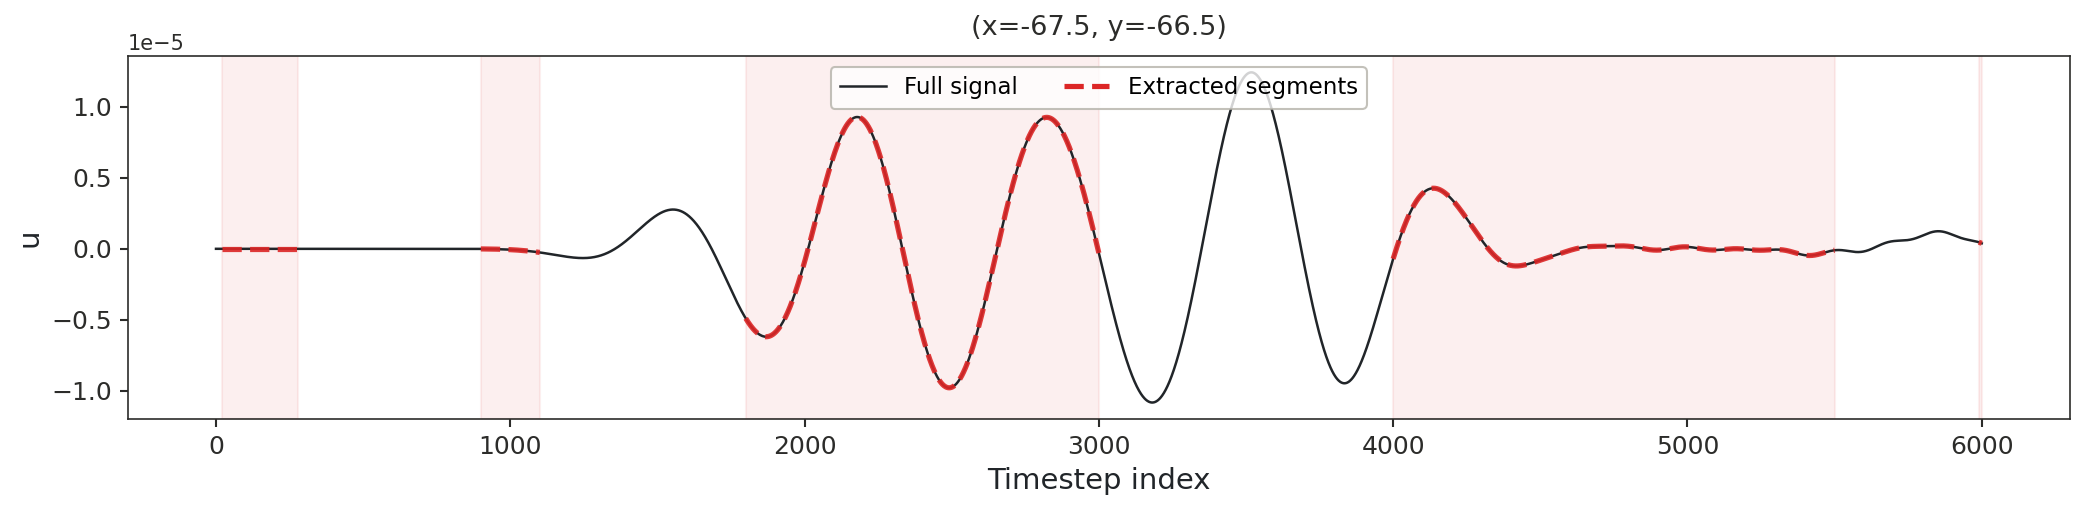

Saved: ./signal_point0_u.jpg


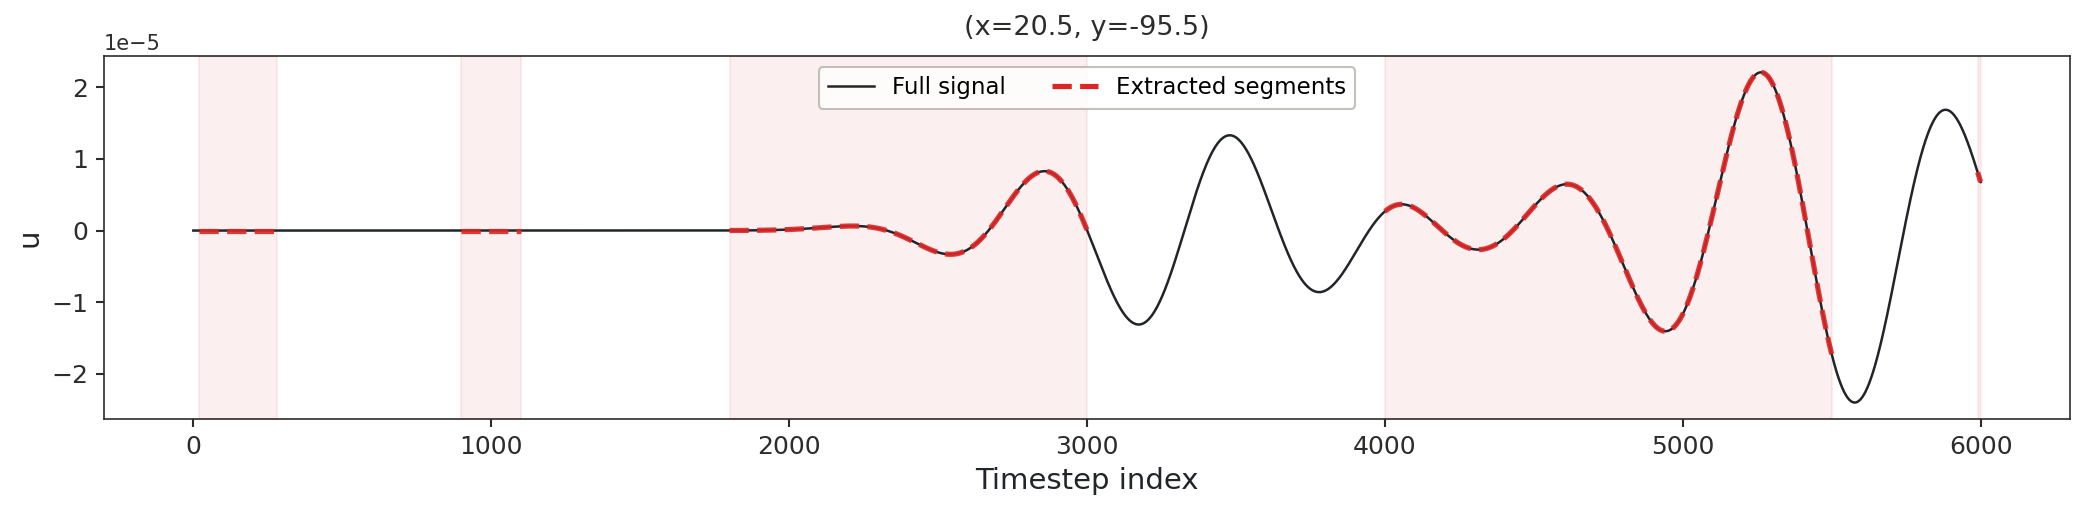

Saved: ./signal_point4_u.jpg


In [ ]:
visualize_extracted_signals(
    df,
    full_dataset=dataset,
    point_indices=[0, 4],
    component='u',
    time_index_ranges=[[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]]
)

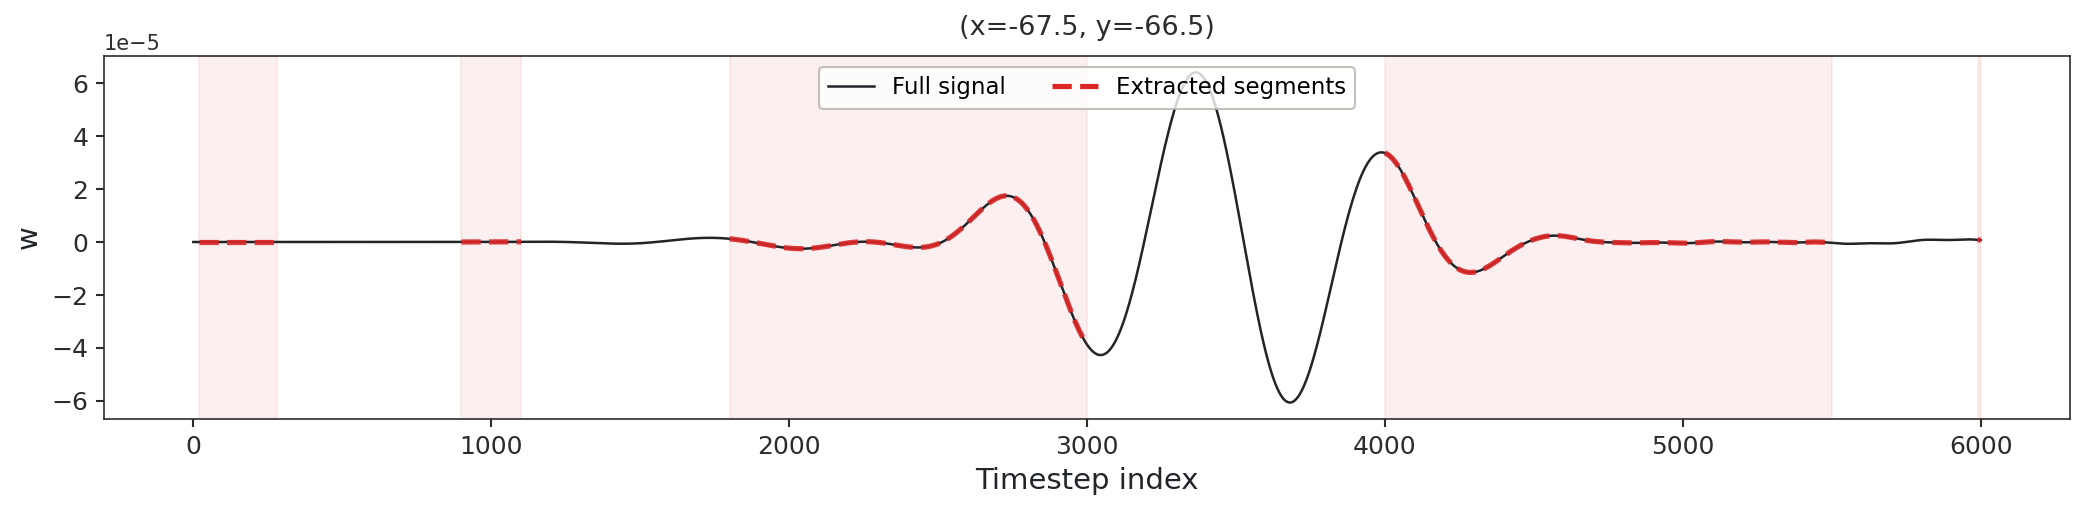

Saved: ./signal_point0_w.jpg


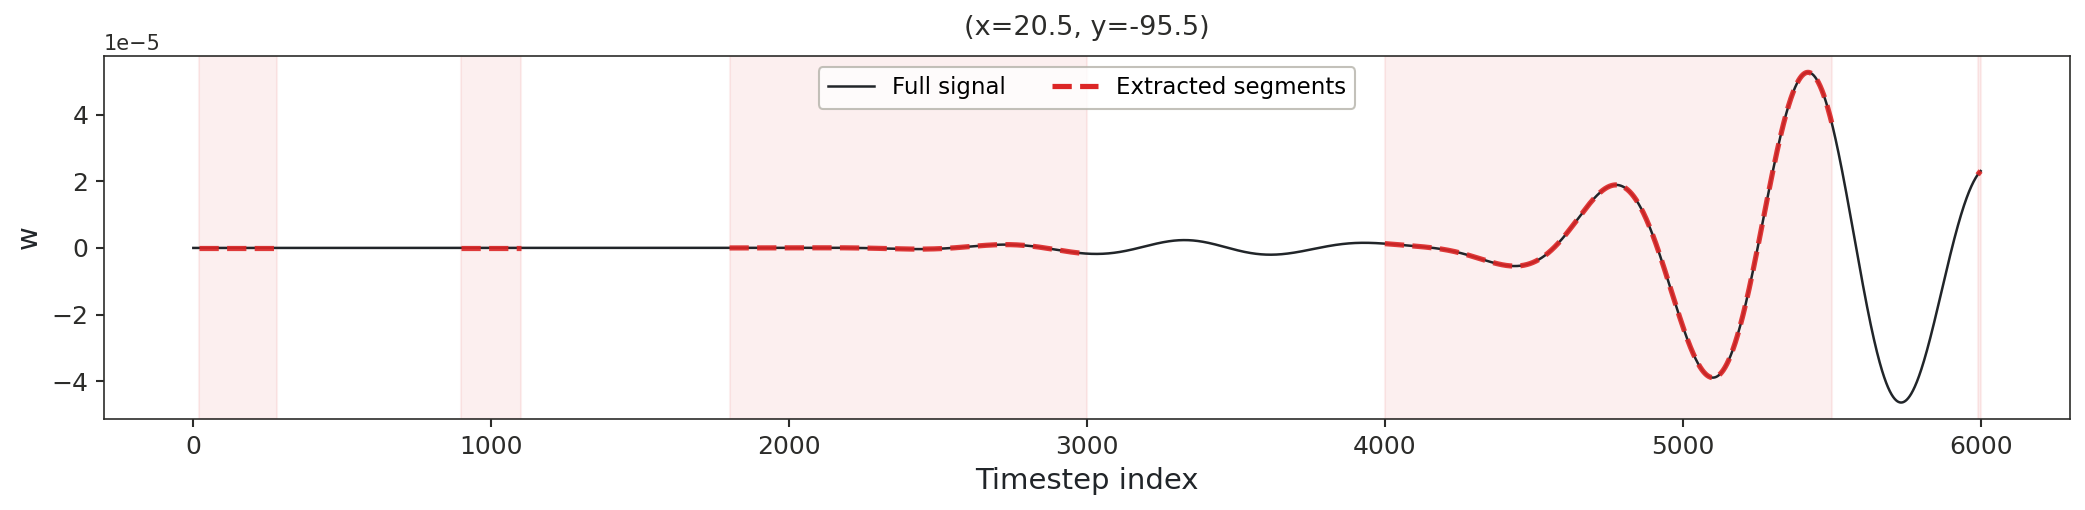

Saved: ./signal_point4_w.jpg


In [ ]:
visualize_extracted_signals(
    df,
    full_dataset=dataset,
    point_indices=[0, 4],
    component='w',
    time_index_ranges=[[20, 280], [900, 1100], [1800, 3000], [4000, 5500], [5990, 6000]]
)